<a href="https://colab.research.google.com/github/marcusslongweek/Homework/blob/main/ExtraCredit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bonus Assignment: Image Classification with a Pretrained Model**

In [1]:
import torch
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device being used:", device)

Device being used: cuda


In [3]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

model = model.to(device)
model.eval()

print("ResNet18 loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]


ResNet18 loaded successfully!


In [4]:
preprocess = weights.transforms()

categories = weights.meta["categories"]

print("Number of classes:", len(categories))

Number of classes: 1000


In [5]:
uploaded = files.upload()

Saving 133705889598473223.jpg to 133705889598473223.jpg
Saving 133750701791659184.jpg to 133750701791659184.jpg
Saving 133962299331151277.jpg to 133962299331151277.jpg


In [6]:
image_files = list(uploaded.keys())

print("Uploaded images:")
for filename in image_files:
    print(filename)

Uploaded images:
133705889598473223.jpg
133750701791659184.jpg
133962299331151277.jpg


In [7]:
def classify_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image)
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Make prediction
    with torch.no_grad():
        output = model(input_batch)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)

    predictions = []

    for i in range(5):
        label = categories[top5_catid[i]]
        confidence = top5_prob[i].item() * 100

        predictions.append((label, confidence))

    return image, predictions


Image: 133705889598473223.jpg
Top-5 Predictions:
brown bear: 73.93%
Irish terrier: 12.24%
Airedale: 1.43%
Border terrier: 1.17%
baboon: 1.15%


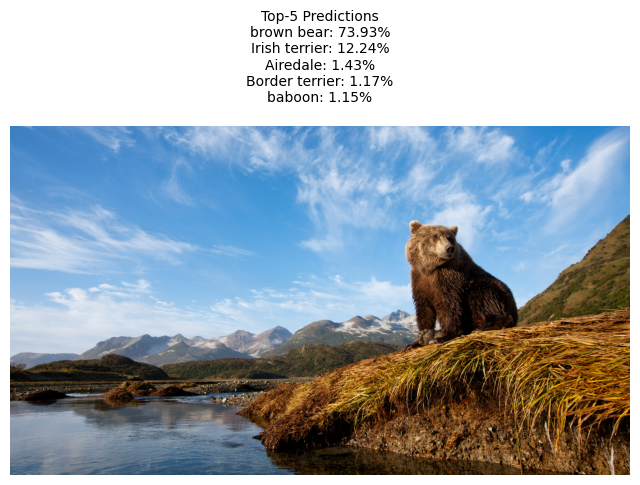


Image: 133750701791659184.jpg
Top-5 Predictions:
kite: 78.55%
great grey owl: 18.78%
bald eagle: 1.73%
vulture: 0.35%
ruddy turnstone: 0.17%


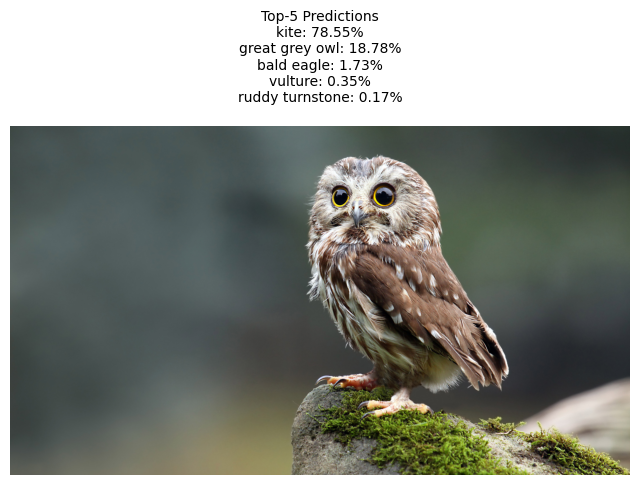


Image: 133962299331151277.jpg
Top-5 Predictions:
plastic bag: 24.35%
bonnet: 12.07%
handkerchief: 9.77%
shower cap: 5.27%
diaper: 4.64%


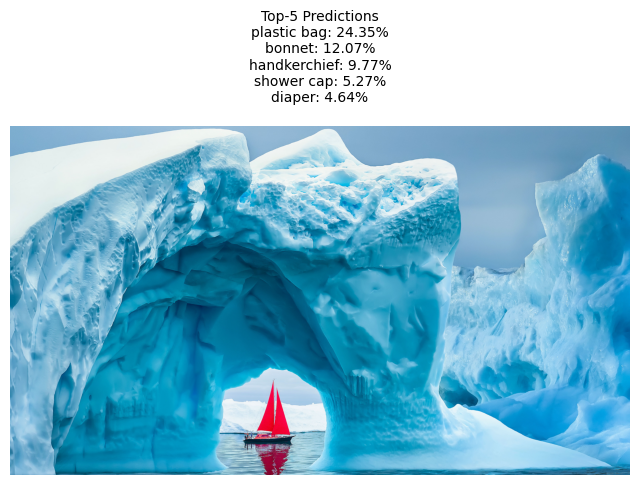

In [8]:
for image_path in image_files:
    image, predictions = classify_image(image_path)

    prediction_text = ""

    print("\nImage:", image_path)
    print("Top-5 Predictions:")

    for label, confidence in predictions:
        print(f"{label}: {confidence:.2f}%")
        prediction_text += f"{label}: {confidence:.2f}%\n"

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Top-5 Predictions\n{prediction_text}",
        fontsize=10
    )
    plt.show()

The model was able to classify the bear correctly, while the other images produced less accurate predictions. This shows that pretrained models can perform well on familiar ImageNet classes but may struggle with images that do not match those categories.